<a href="https://colab.research.google.com/github/snehalathaArakkonam/Img_CapGenerator/blob/main/img_caption_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Only required minimal libraries
!pip install tensorflow pillow tqdm

In [ ]:
# Install kagglehub (if not installed)
!pip install kagglehub

In [ ]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Dataset path:", path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Dataset path: /kaggle/input/flickr8k


In [ ]:
# Set correct paths
IMAGES_PATH = os.path.join(path, "Images")
CAPTIONS_PATH = os.path.join(path, "captions.txt")

print("Images Path:", IMAGES_PATH)
print("Captions Path:", CAPTIONS_PATH)

Images Path: /kaggle/input/flickr8k/Images
Captions Path: /kaggle/input/flickr8k/captions.txt


In [ ]:
import re

# Load captions
def load_captions(path):
    with open(path, 'r') as f:
        data = f.readlines()[1:]  # skip header
    return data

# Clean text (remove symbols, numbers)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]', '', text)
    return text

# Process captions
captions_data = load_captions(CAPTIONS_PATH)

# Create dictionary: {image: [captions]}
mapping = {}

for line in captions_data:
    img, caption = line.strip().split(',', 1)
    caption = clean_text(caption)

    # add start & end tokens
    caption = "start " + caption + " end"

    if img not in mapping:
        mapping[img] = []
    mapping[img].append(caption)

# check sample
list(mapping.items())[:2]

[('1000268201_693b08cb0e.jpg',
  ['start a child in a pink dress is climbing up a set of stairs in an entry way  end',
   'start a girl going into a wooden building  end',
   'start a little girl climbing into a wooden playhouse  end',
   'start a little girl climbing the stairs to her playhouse  end',
   'start a little girl in a pink dress going into a wooden cabin  end']),
 ('1001773457_577c3a7d70.jpg',
  ['start a black dog and a spotted dog are fighting end',
   'start a black dog and a tricolored dog playing with each other on the road  end',
   'start a black dog and a white dog with brown spots are staring at each other in the street  end',
   'start two dogs of different breeds looking at each other on the road  end',
   'start two dogs on pavement moving toward each other  end'])]

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# collect all captions into one list
all_captions = []
for caps in mapping.values():
    all_captions.extend(caps)

# create tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

# vocab size
vocab_size = len(tokenizer.word_index) + 1

print("Vocab Size:", vocab_size)

Vocab Size: 8779


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# find max caption length
max_length = max(len(caption.split()) for caption in all_captions)

print("Max Length:", max_length)

# example: convert one caption to sequence
sample = all_captions[0]
seq = tokenizer.texts_to_sequences([sample])[0]

# padding
padded = pad_sequences([seq], maxlen=max_length)

print("Sample Caption:", sample)
print("Sequence:", seq[:10])
print("Padded:", padded[0][:10])

Max Length: 37
Sample Caption: start a child in a pink dress is climbing up a set of stairs in an entry way  end
Sequence: [3, 1, 42, 4, 1, 90, 170, 7, 119, 53]
Padded: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
# Image Feature Extraction Setup

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# load pretrained model (remove last layer)
base_model = InceptionV3(weights='imagenet')
feature_extractor_model = tf.keras.Model(inputs=base_model.input, outputs=base_model.layers[-2].output)

print("Model Loaded ✅")

Model Loaded ✅


In [ ]:
# function to extract features from single image
def extract_features(img_path):
    img = load_img(img_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    feature = feature_extractor_model.predict(img, verbose=0)
    return feature.flatten()

In [ ]:
image_features = {}

# increased images for better accuracy
images = list(mapping.keys())[:700]

for img in images:
    path = IMAGES_PATH + "/" + img

    try:
        image_features[img] = extract_features(path)
    except:
        continue  # skip error images

print("Features Extracted:", len(image_features))

Features Extracted: 700


In [ ]:
#data training
from tensorflow.keras.utils import to_categorical

X_img, X_seq, y = [], [], []

for img, caps in mapping.items():
    if img not in image_features:
        continue

    for cap in caps:
        seq = tokenizer.texts_to_sequences([cap])[0]

        for i in range(1, len(seq)):
            in_seq = seq[:i]
            out_seq = seq[i]

            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical(out_seq, num_classes=vocab_size)

            X_img.append(image_features[img])
            X_seq.append(in_seq)
            y.append(out_seq)

print("Data Prepared ✅")
print(len(X_img))

Data Prepared ✅
41844


In [ ]:
#Build Model (CNN + LSTM)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

# Image feature input
image_input = Input(shape=(2048,))
fe1 = Dense(256, activation='relu')(image_input)
fe2 = Dropout(0.3)(fe1)

# Caption input
seq_input = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(seq_input)
se2 = LSTM(256)(se1)

# Combine both
decoder = add([fe2, se2])
decoder = Dense(256, activation='relu')(decoder)
output = Dense(vocab_size, activation='softmax')(decoder)

# Final model
model = Model(inputs=[image_input, seq_input], outputs=output)

model.compile(loss='categorical_crossentropy', optimizer='adam')

print("Model Built ✅")

Model Built ✅


In [ ]:
#Train Model (FAST VERSION)
import numpy as np

# convert to numpy arrays
X_img = np.array(X_img)
X_seq = np.array(X_seq)
y = np.array(y)

# train model
model.fit(
    [X_img, X_seq],
    y,
    epochs=3,
    batch_size=64
)

Epoch 1/3
654/654 ━━━━━━━━━━━━━━━━━━━━ 213s 320ms/step - loss: 4.7418
Epoch 2/3
654/654 ━━━━━━━━━━━━━━━━━━━━ 210s 321ms/step - loss: 3.7695
Epoch 3/3
654/654 ━━━━━━━━━━━━━━━━━━━━ 214s 327ms/step - loss: 3.4136


In [ ]:
# generate caption (greedy search)
def generate_caption(model, image_feature, tokenizer, max_length):
    in_text = "start"

    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = pad_sequences([seq], maxlen=max_length)

        yhat = model.predict([image_feature.reshape(1,2048), seq], verbose=0)
        yhat = np.argmax(yhat)

        word = tokenizer.index_word.get(yhat)

        if word is None:
            break

        in_text += " " + word

        if word == "end":
            break

    return in_text.replace("start ", "").replace(" end", "")

In [ ]:
# test on one image
import random

img = random.choice(list(image_features.keys()))
feature = image_features[img]

caption = generate_caption(model, feature, tokenizer, max_length)

print("Image:", img)
print("Generated Caption:", caption)

Image: 1313961775_824b87d155.jpg
Generated Caption: a girl in a blue jacket is jumping through the beach


In [ ]:
model.fit([X_img, X_seq], y, epochs=5, batch_size=64)

Epoch 1/5
654/654 ━━━━━━━━━━━━━━━━━━━━ 211s 323ms/step - loss: 3.1538
Epoch 2/5
654/654 ━━━━━━━━━━━━━━━━━━━━ 209s 319ms/step - loss: 2.9370
Epoch 3/5
654/654 ━━━━━━━━━━━━━━━━━━━━ 260s 316ms/step - loss: 2.7335
Epoch 4/5
654/654 ━━━━━━━━━━━━━━━━━━━━ 207s 316ms/step - loss: 2.5333
Epoch 5/5
654/654 ━━━━━━━━━━━━━━━━━━━━ 206s 315ms/step - loss: 2.3409


In [ ]:
# TAKES A RANDOM IMG AND SHOWS THE O/P
import random

img = random.choice(list(image_features.keys()))
feature = image_features[img]

caption = generate_caption(model, feature, tokenizer, max_length)

print("Image:", img)
print("Generated Caption:", caption)

Image: 1251558317_4ef844b775.jpg
Generated Caption: a man in a blue shirt and black pants is standing on a police motorcycle


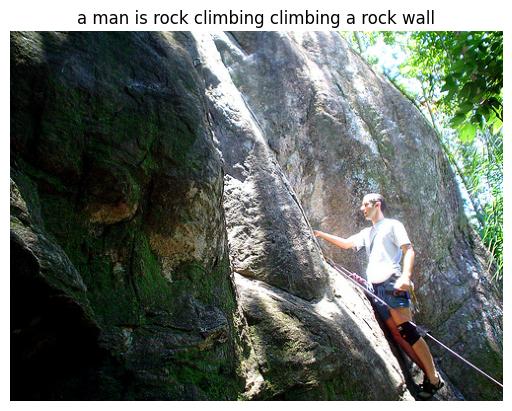

In [ ]:
# pick random image every run
import random
import matplotlib.pyplot as plt
from PIL import Image

# pick random image
img = random.choice(list(image_features.keys()))

# generate caption
feature = image_features[img]
caption = generate_caption(model, feature, tokenizer, max_length)

# show image
img_path = IMAGES_PATH + "/" + img
image = Image.open(img_path)

plt.imshow(image)
plt.axis('off')
plt.title(caption)
plt.show()

In [ ]:
caption = generate_caption(model, feature, tokenizer, max_length)

# remove repeated words
caption = " ".join(dict.fromkeys(caption.split()))

Saving dog.jpg to dog.jpg


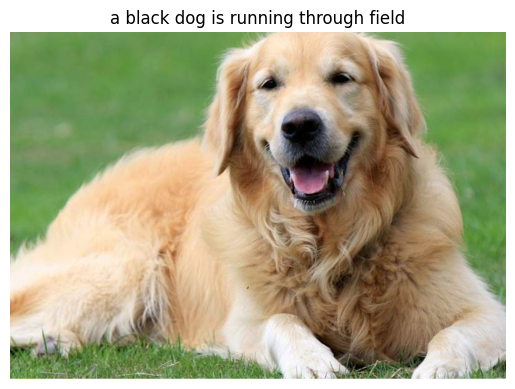

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
    path = fn

    # extract features (pass path only)
    feature = extract_features(path)

    # generate caption
    caption = generate_caption(model, feature, tokenizer, max_length) # Corrected argument order

    # remove duplicates safely
    if isinstance(caption, str):
        caption = " ".join(dict.fromkeys(caption.split()))

    # show image
    img = Image.open(path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption)
    plt.show()

### Continue Training the Model

To further improve caption generation accuracy, we will train the model for an additional 10 epochs. This allows the model to refine its understanding of image features and their corresponding captions.

In [67]:
# Continue training the model for more epochs
model.fit(
    [X_img, X_seq],
    y,
    epochs=10,
    batch_size=64
)

Epoch 1/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 221s 337ms/step - loss: 2.1606
Epoch 2/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 221s 337ms/step - loss: 1.9914
Epoch 3/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 217s 332ms/step - loss: 1.8303
Epoch 4/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 254s 320ms/step - loss: 1.6852
Epoch 5/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 263s 321ms/step - loss: 1.5531
Epoch 6/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 206s 316ms/step - loss: 1.4392
Epoch 7/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 210s 321ms/step - loss: 1.3323
Epoch 8/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 209s 320ms/step - loss: 1.2378
Epoch 9/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 209s 320ms/step - loss: 1.1555
Epoch 10/10
654/654 ━━━━━━━━━━━━━━━━━━━━ 261s 318ms/step - loss: 1.0848


### Test Caption Generation After Additional Training

Now, let's test the caption generation again on a random image to see if the increased training improved accuracy.

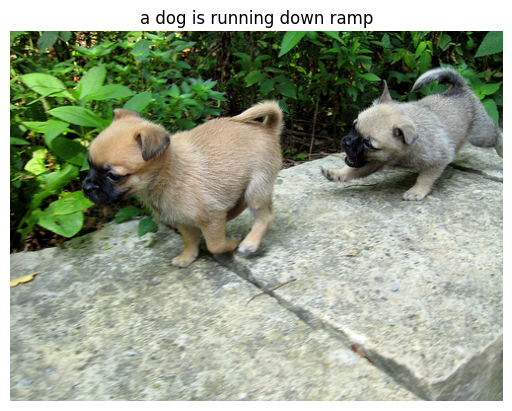

In [71]:
# pick random image every run
import random
import matplotlib.pyplot as plt
from PIL import Image

# pick random image
img = random.choice(list(image_features.keys()))

# generate caption
feature = image_features[img]
caption = generate_caption(model, feature, tokenizer, max_length)

# remove repeated words for better readability (optional)
caption = " ".join(dict.fromkeys(caption.split()))

# show image
img_path = IMAGES_PATH + "/" + img
image = Image.open(img_path)

plt.imshow(image)
plt.axis('off')
plt.title(caption)
plt.show()